In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

periodic_table = pd.read_csv("../periodic_table_dataset.csv")
real_atomic_number = periodic_table['Atomic Number'].values

df_layers = pd.read_csv("../Results/intevention/first_number_layer_sweep.csv", index_col=0)
df_layers

,H,He,Li,Be,B,C,N,O,F,Ne,...,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn
0,13.0,12.0,12.0,13.0,13.0,13.0,13.0,12.0,12.0,12.0,...,44.0,45.0,45.0,25.0,29.0,29.0,29.0,47.0,48.0,48.0
4,6.0,6.0,6.0,6.0,13.0,13.0,6.0,6.0,6.0,6.0,...,44.0,45.0,45.0,45.0,45.0,47.0,48.0,47.0,50.0,50.0
8,13.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,14.0,12.0,...,42.0,45.0,45.0,25.0,29.0,47.0,47.0,49.0,50.0,50.0
12,4.0,4.0,4.0,12.0,12.0,12.0,12.0,12.0,12.0,16.0,...,75.0,45.0,75.0,42.0,29.0,46.0,47.0,49.0,33.0,34.0
16,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,...,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,17.0,17.0
20,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,17.0,17.0
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,17.0,NaN,17.0,17.0
31,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,...,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0


In [2]:
LAYERS = [0, 4, 8, 12, 16, 20, 24, 28, 31]
TOTAL_DEPTH = 32  # tổng số layer của model 8B

results = []
for layer in LAYERS:
    pred_raw = df_layers.loc[layer]
    pred_numeric = pd.to_numeric(pred_raw, errors='coerce')

    n_total = len(pred_numeric)
    n_valid = pred_numeric.notna().sum()
    pct_valid = (n_valid / n_total) * 100

    if n_valid > 1:
        valid_mask = pred_numeric.notna().values
        pred_valid = pred_numeric.values[valid_mask]
        real_valid = real_atomic_number[:n_total][valid_mask]
        r2 = r2_score(real_valid, pred_valid)
        pct_within_2 = (np.sum(np.abs(pred_valid - real_valid) <= 2) / len(real_valid)) * 100
    else:
        r2 = np.nan
        pct_within_2 = np.nan

    results.append({
        "layer": layer,
        "depth_pct": layer / (TOTAL_DEPTH - 1) * 100,
        "pct_valid": pct_valid,
        "r2": r2,
        "pct_within_2": pct_within_2
    })

summary_df = pd.DataFrame(results)
summary_df

,layer,depth_pct,pct_valid,r2,pct_within_2
0,0,0.000000,100.0,0.562641,50.000000
1,4,12.903226,100.0,0.960432,68.000000
2,8,25.806452,100.0,0.832221,62.000000
3,12,38.709677,100.0,0.337911,30.000000
4,16,51.612903,100.0,-0.647539,14.000000
5,20,64.516129,72.0,-0.269868,13.888889
6,24,77.419355,2.0,NaN,NaN
7,28,90.322581,14.0,-10.995557,0.000000
8,31,100.000000,100.0,-0.346939,10.000000


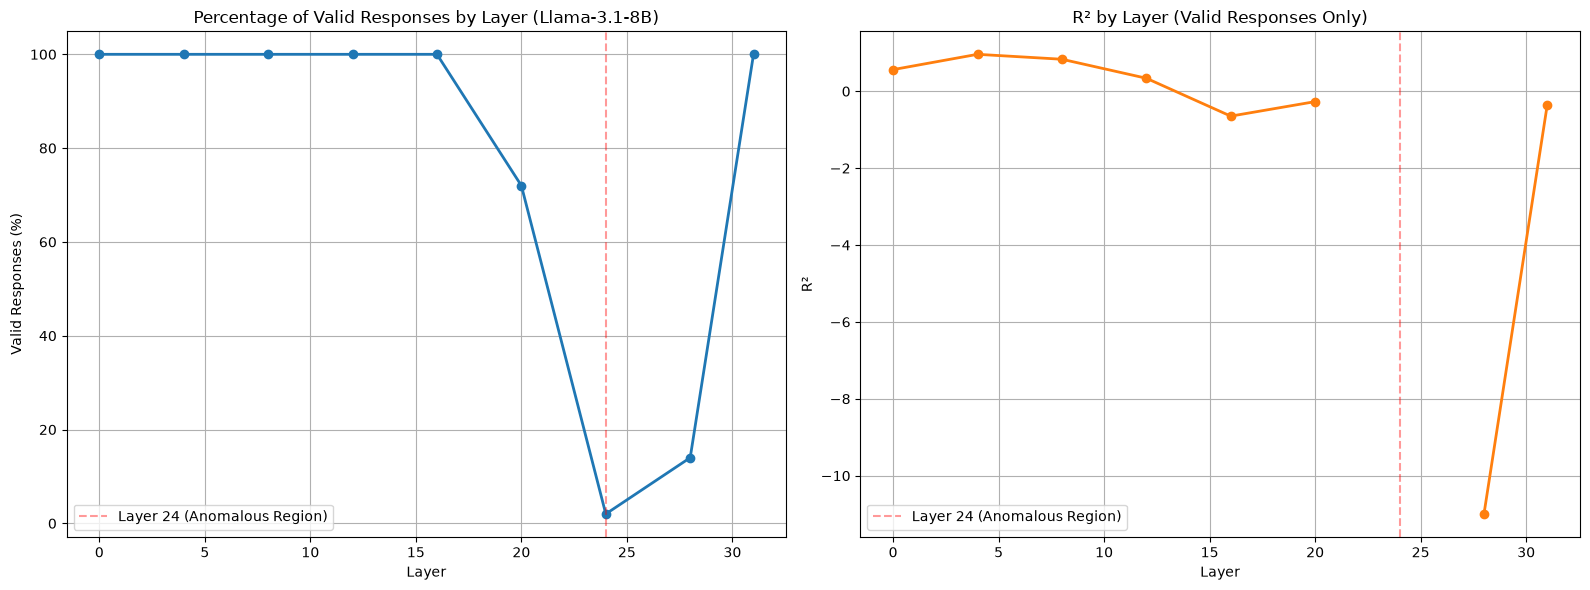

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Percentage of valid responses by layer
axes[0].plot(
    summary_df["layer"],
    summary_df["pct_valid"],
    marker='o',
    linewidth=2,
    color='tab:blue'
)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Valid Responses (%)")
axes[0].set_title("Percentage of Valid Responses by Layer (Llama-3.1-8B)")
axes[0].grid(True)
axes[0].axvline(
    x=24,
    color='red',
    linestyle='--',
    alpha=0.4,
    label="Layer 24 (Anomalous Region)"
)
axes[0].legend()

# Subplot 2: R² by layer
axes[1].plot(
    summary_df["layer"],
    summary_df["r2"],
    marker='o',
    linewidth=2,
    color='tab:orange'
)
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("R²")
axes[1].set_title("R² by Layer (Valid Responses Only)")
axes[1].grid(True)
axes[1].axvline(
    x=24,
    color='red',
    linestyle='--',
    alpha=0.4,
    label="Layer 24 (Anomalous Region)"
)
axes[1].legend()

plt.tight_layout()
plt.savefig("../Results/intevention/layer_sweep_comparison.png", dpi=300)
plt.show()

In [4]:
print(summary_df[["layer", "depth_pct", "pct_valid", "r2", "pct_within_2"]].round(2).to_string(index=False))

 layer  depth_pct  pct_valid     r2  pct_within_2
     0       0.00      100.0   0.56         50.00
     4      12.90      100.0   0.96         68.00
     8      25.81      100.0   0.83         62.00
    12      38.71      100.0   0.34         30.00
    16      51.61      100.0  -0.65         14.00
    20      64.52       72.0  -0.27         13.89
    24      77.42        2.0    NaN           NaN
    28      90.32       14.0 -11.00          0.00
    31     100.00      100.0  -0.35         10.00


In [5]:
df_70b_raw = pd.read_csv(
    "/mnt/d/Anh Nguyen/LLM-knowledge-representation/Results/intervention/first_number_per_layer.csv",
    header=None
)

# Dòng 9 trong file 70B ứng với transform polar_3d, prompt atomic (theo mapping của researcher)
pred_70b = pd.to_numeric(df_70b_raw.iloc[9, 1:52], errors='coerce').values
pred_70b = np.nan_to_num(pred_70b)

pred_8b_layer8 = pd.to_numeric(df_layers.loc[8], errors='coerce').values
pred_8b_layer8 = np.nan_to_num(pred_8b_layer8)

n = min(len(pred_70b), len(pred_8b_layer8), len(real_atomic_number))
real = real_atomic_number[:n]
pred_70b, pred_8b_layer8 = pred_70b[:n], pred_8b_layer8[:n]

r2_70b = r2_score(real, pred_70b)
r2_8b = r2_score(real, pred_8b_layer8)
pct2_70b = (np.sum(np.abs(pred_70b - real) <= 2) / n) * 100
pct2_8b = (np.sum(np.abs(pred_8b_layer8 - real) <= 2) / n) * 100

print(f"70B (layer 20, 25% depth): R²={r2_70b:.3f}, Abs.err≤2={pct2_70b:.1f}%")
print(f"8B  (layer 8,  25% depth): R²={r2_8b:.3f}, Abs.err≤2={pct2_8b:.1f}%")

70B (layer 20, 25% depth): R²=0.816, Abs.err≤2=72.0%
8B  (layer 8,  25% depth): R²=0.832, Abs.err≤2=62.0%


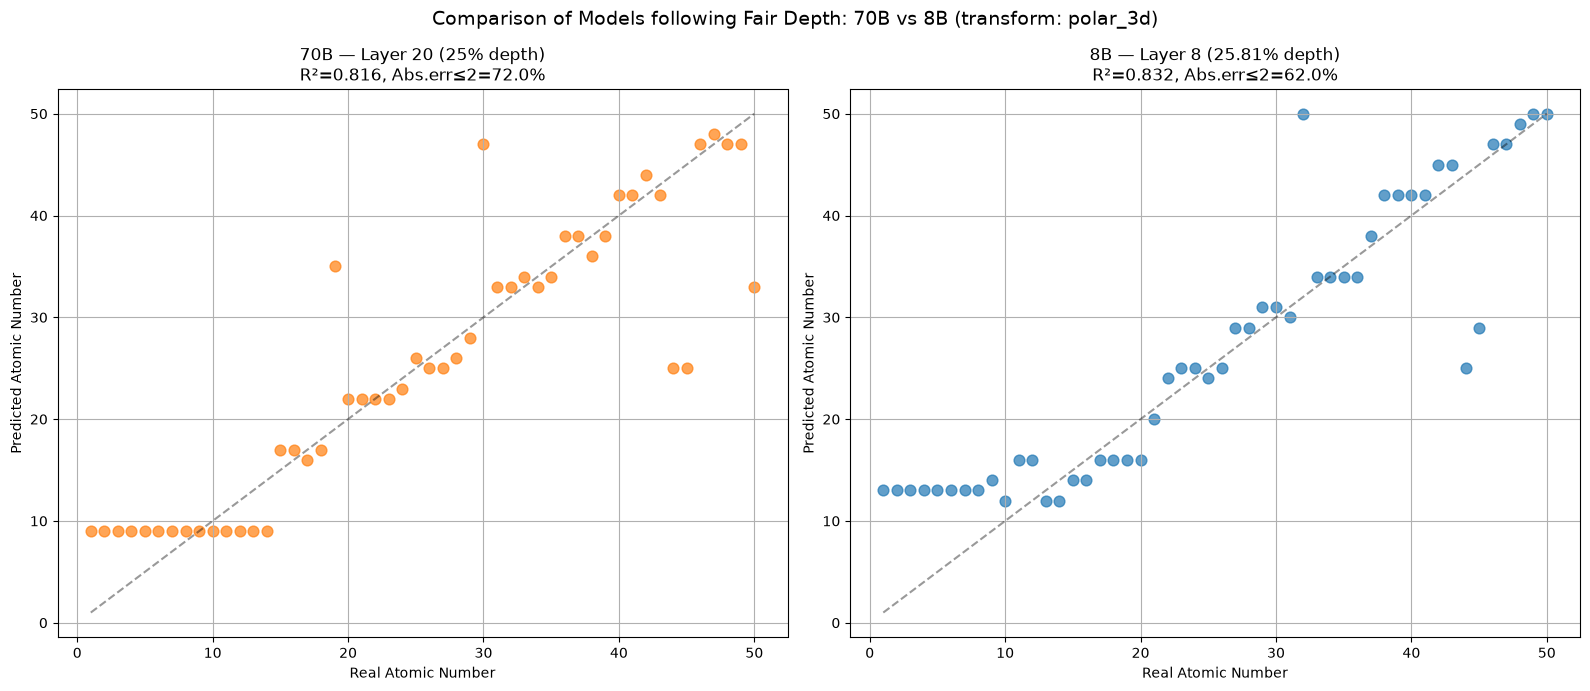

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(real, pred_70b, s=60, alpha=0.7, color='tab:orange')
axes[0].plot([real.min(), real.max()], [real.min(), real.max()], 'k--', alpha=0.4)
axes[0].set_title(f"70B — Layer 20 (25% depth)\nR²={r2_70b:.3f}, Abs.err≤2={pct2_70b:.1f}%")
axes[0].set_xlabel("Real Atomic Number")
axes[0].set_ylabel("Predicted Atomic Number")
axes[0].grid(True)

axes[1].scatter(real, pred_8b_layer8, s=60, alpha=0.7, color='tab:blue')
axes[1].plot([real.min(), real.max()], [real.min(), real.max()], 'k--', alpha=0.4)
axes[1].set_title(f"8B — Layer 8 (25.81% depth)\nR²={r2_8b:.3f}, Abs.err≤2={pct2_8b:.1f}%")
axes[1].set_xlabel("Real Atomic Number")
axes[1].set_ylabel("Predicted Atomic Number")
axes[1].grid(True)

fig.suptitle("Comparison of Models following Fair Depth: 70B vs 8B (transform: polar_3d)", fontsize=14)
plt.tight_layout()
plt.savefig("../Results/intevention/comparison_70B_vs_8B_fair_depth.png", dpi=300)
plt.show()